In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('/content/diabetes.csv')

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


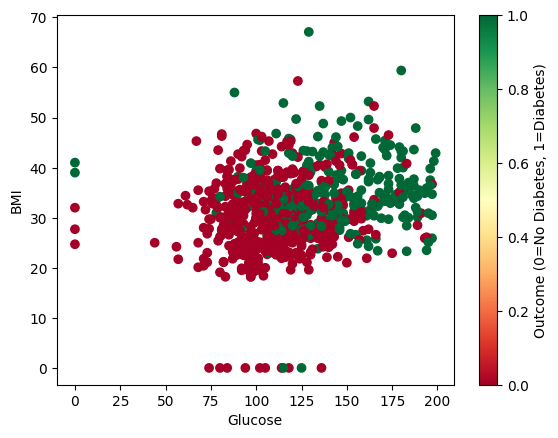

In [7]:
import matplotlib.pyplot as plt

plt.scatter(df['Glucose'], df['BMI'], c=df['Outcome'], cmap='RdYlGn')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.colorbar(label='Outcome (0=No Diabetes, 1=Diabetes)')
plt.show()

In [8]:
x= df.iloc[:,0:8]
y= df.iloc[:,-1]
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [9]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [10]:
x.shape

(768, 8)

In [11]:
y.shape

(768,)

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [14]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
376,0,98,82,15,84,25.2,0.299,22
216,5,109,62,41,129,35.8,0.514,25
200,0,113,80,16,0,31.0,0.874,21
602,1,124,74,36,0,27.8,0.100,30
11,10,168,74,0,0,38.0,0.537,34
...,...,...,...,...,...,...,...,...
542,10,90,85,32,0,34.9,0.825,56
2,8,183,64,0,0,23.3,0.672,32
10,4,110,92,0,0,37.6,0.191,30
597,1,89,24,19,25,27.8,0.559,21


In [15]:
y_train

,Outcome
376,0
216,1
200,0
602,0
11,1
...,...
542,1
2,1
10,0
597,0


In [16]:
x_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
75,1,0,48,20,0,24.7,0.140,22
683,4,125,80,0,0,32.3,0.536,27
398,3,82,70,0,0,21.1,0.389,25
28,13,145,82,19,110,22.2,0.245,57
486,1,139,62,41,480,40.7,0.536,21
...,...,...,...,...,...,...,...,...
616,6,117,96,0,0,28.7,0.157,30
609,1,111,62,13,182,24.0,0.138,23
692,2,121,70,32,95,39.1,0.886,23
475,0,137,84,27,0,27.3,0.231,59


In [17]:
y_test

,Outcome
75,0
683,1
398,0
28,0
486,0
...,...
616,0
609,0
692,0
475,0


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
x_train = scaler.fit_transform(x_train)
x_train

array([[-1.13765886, -0.71935219,  0.68074296, ..., -0.83348048,
        -0.5270289 , -0.9449879 ],
       [ 0.36972685, -0.37052216, -0.32003802, ...,  0.48631524,
         0.12462414, -0.69050432],
       [-1.13765886, -0.24367487,  0.58066486, ..., -0.11132811,
         1.21576412, -1.02981576],
       ...,
       [ 0.06824971, -0.33881034,  1.18113345, ...,  0.71043149,
        -0.8543709 , -0.26636501],
       [-0.83618171, -1.00475858, -2.2215219 , ..., -0.509757  ,
         0.26101664, -1.02981576],
       [-1.13765886,  0.13686698, -0.01980373, ..., -0.89573499,
        -0.80890673, -1.02981576]])

In [21]:
x_test = scaler.fit_transform(x_test)

In [22]:
x_test

array([[-0.88242284, -3.62812159, -1.47420141, ..., -1.06356969,
        -0.9764919 , -1.00376441],
       [-0.03661506,  0.09734598,  0.49673308, ..., -0.01177251,
         0.20293378, -0.57269994],
       [-0.31855098, -1.18421486, -0.11918394, ..., -1.5617894 ,
        -0.23488333, -0.74512572],
       ...,
       [-0.60048691, -0.02186898, -0.11918394, ...,  0.92930918,
         1.24535546, -0.91755151],
       [-1.16435876,  0.45499087,  0.7430999 , ..., -0.70374434,
        -0.70546226,  2.18611266],
       [-0.03661506, -0.55833631, -0.73510097, ..., -1.16044574,
         1.48362327, -0.05542257]])

In [23]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(x_train,y_train)

LogisticRegression()

In [24]:
y_pred = clf.predict(x_test)

In [25]:
y_test

,Outcome
75,0
683,1
398,0
28,0
486,0
...,...
616,0
609,0
692,0
475,0


In [26]:
y_pred

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0])

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7727272727272727

In [53]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
import numpy as np


In [57]:
filler_values_dict = {}
for i in range(8):
    if i not in [1, 5]:
        filler_values_dict[i] = x_train[:, i].mean()

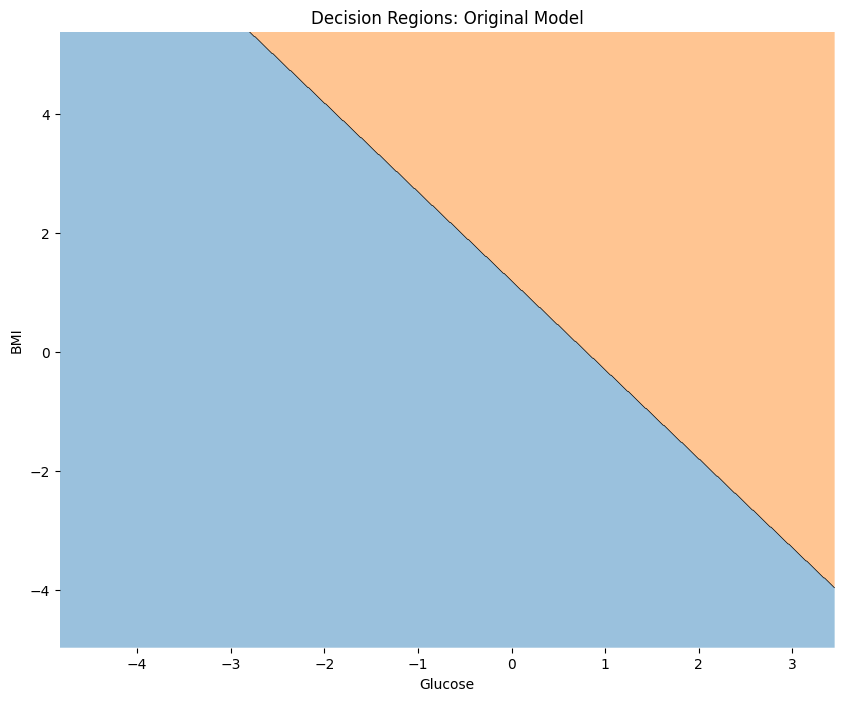

In [59]:
plt.figure(figsize=(10, 8))
plot_decision_regions(
    X=x_train,
    y=y_train.values,
    clf=clf,
    feature_index=[1, 5],
    filler_feature_values=filler_values_dict,
    legend=2
)

plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Decision Regions: Original Model')
plt.show()

In [60]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))

In [63]:

x_test_pred = clf.predict(x_test)
accuracy_score(x_test_pred,y_test)


0.7727272727272727

In [102]:
input_data = (6, 18, 72, 35, 0, 33.5, 0.627, 10)

In [104]:
input_data_as_numpy_array = np.asarray(input_data)


In [105]:
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

In [106]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
std_data = scaler.transform(input_data_reshaped)
print("Scaled input data:")
print(std_data)

Scaled input data:
[[ 0.68185612 -3.21332065  0.13973176  0.94679966 -0.70120553  0.19608867
   0.46894005 -1.99295602]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [107]:
prediction = clf.predict(std_data)
print(f"\nPrediction: {prediction[0]}")


probability = clf.predict_proba(std_data)
print(f"\nPrediction Probabilities:")
print(f"No Diabetes: {probability[0][0]:.2%}")
print(f"Diabetes: {probability[0][1]:.2%}")




Prediction: 0

Prediction Probabilities:
No Diabetes: 98.84%
Diabetes: 1.16%


In [108]:
# Interpret result
if prediction[0] == 0:
    print("\n Result: The person does NOT have diabetes")
else:
    print("\nResult: The person has diabetes")


 Result: The person does NOT have diabetes


In [113]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 23.8 MB/s eta 0:00:00


In [114]:
!pip install pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.2 MB/s eta 0:00:00


In [115]:
!pip install mysql-connector-python sqlalchemy pymysql

In [116]:
import mysql.connector
import pandas as pd
from sqlalchemy import create_engine

In [124]:
import sqlite3
import pandas as pd

# SQLite database (file-based, works everywhere)
conn = sqlite3.connect('diabetes.db')

# Save your diabetes data
df = pd.read_csv('diabetes.csv')
df.to_sql('diabetes', conn, if_exists='replace', index=False)

# Query
result = pd.read_sql("SELECT * FROM diabetes LIMIT 5", conn)
print(result)

conn.close()

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
